# Networks

### Problem 4.1. 
The time series included in DTU Learn represent the hourly capacity factor for wind power in Spain $g^{W,Spain}_t$ and Denmark $g^{W,Denmark}_t$. 
Assuming a constant electricity demand of 1 GW in every country:

a) Calculate the required wind power capacity in every country to cover, on average, the electricity
demand.

In [1]:
import pandas as pd
import numpy as np

# Load data (semicolon-separated file)
data = pd.read_csv('onshore_wind.csv', sep=';'  )
data['utc_time'] = pd.to_datetime(data['utc_time'])

# Get ESP an DNK
cf_esp = data['ESP'].to_numpy()
cf_dnk = data['DNK'].to_numpy()

# Handle missing values
data.ffill(inplace=True)

# Parameters
d = 1 # GW demand each hour in every country

# Capacities to match avg. demand
cap_esp = d / cf_esp.mean()
cap_dnk = d / cf_dnk.mean()

print(f"Capacities to meet average demand: ESP = {cap_esp:.2f} GW, DNK = {cap_dnk:.2f} GW")

# Wind generation
wind_esp = cap_esp * cf_esp
wind_dnk = cap_dnk * cf_dnk

print(f"Average wind generation: ESP = {wind_esp.mean():.2f} GW, DNK = {wind_dnk.mean():.2f} GW")

Capacities to meet average demand: ESP = 4.30 GW, DNK = 3.63 GW
Average wind generation: ESP = 1.00 GW, DNK = 1.00 GW


b) Calculate the required backup energy and backup power capacity to ensure that demand is covered
every hour, assuming the capacity found in (a).

In [2]:
# Backup power
backup_esp = np.maximum(0, d - wind_esp)
backup_dnk = np.maximum(0, d - wind_dnk)

Bpower_esp = backup_esp.max()
Benergy_esp = backup_esp.sum()
Bpower_dnk = backup_dnk.max()
Benergy_dnk = backup_dnk.sum()
print(f"Maximum backup power needed: ESP = {Bpower_esp:.2f} GW, DNK = {Bpower_dnk:.2f} GW")
print(f"Total backup energy needed: ESP = {Benergy_esp:.2f} GWh, DNK = {Benergy_dnk:.2f} GWh")

Maximum backup power needed: ESP = 0.90 GW, DNK = 0.99 GW
Total backup energy needed: ESP = 2096.68 GWh, DNK = 2954.31 GWh


c) If we assume that Spain and Denmark can be connected through an ideal interconnection (without any
losses) and the installed capacities are those calculated in section (a). Calculate the required backup
energy and backup power capacity to ensure the hourly supply of electricity demand in both countries.

In [3]:
# Backup with ideal interconnector
wind_tot = wind_esp + wind_dnk
backup_tot = np.maximum(0, 2*d - wind_tot)
Bpower_tot = backup_tot.max()
Benergy_tot = backup_tot.sum()
print(f"Maximum backup power needed with combined wind: {Bpower_tot:.2f} GW")
print(f"Total backup energy needed with combined wind: {Benergy_tot:.2f} GWh")

Maximum backup power needed with combined wind: 1.72 GW
Total backup energy needed with combined wind: 3456.69 GWh


### Problem 4.2. 
Consider the simplified network plotted in Fig. 1, which represents Denmark and its neighbouring countries. Let us assume the following convention names for the regions Germany=0, DK1=1, DK2=2, Norway=3, and Sweden=4.

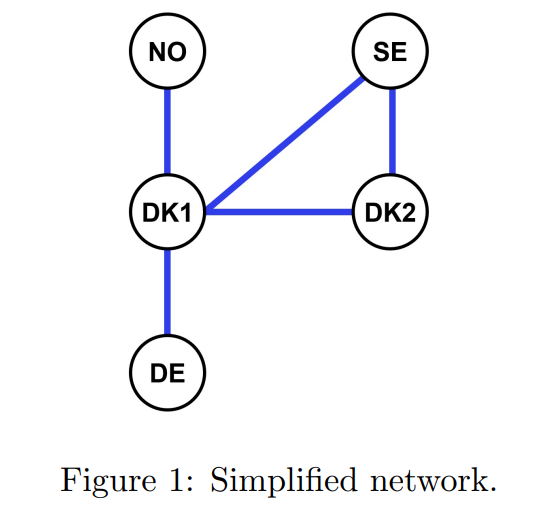

a) Create a list of the nodes and links. Sort the nodes and links in ascending order. Link (0,1) before
(1,2), before (1,3) etc.


In [11]:
# Matrices
laplacian_matrix = np.array([[1, -1, 0, 0, 0], 
                         [-1, 4, -1, -1, -1],
                         [0, -1, 2, 0, -1], 
                         [0, -1, 0, 1, 0], 
                         [0, -1, -1, 0, 2]])

degree_matrix = np.array([[1, 0, 0, 0, 0], 
                         [0, 4, 0, 0, 0],
                         [0, 0, 2, 0, 0], 
                         [0, 0, 0, 1, 0], 
                         [0, 0, 0, 0, 2]])

adjacency_matrix = degree_matrix - laplacian_matrix
print("Laplacian Matrix:\n", laplacian_matrix)
print("Degree Matrix:\n", degree_matrix)
print("Adjacency Matrix:\n", adjacency_matrix)

Laplacian Matrix:
 [[ 1 -1  0  0  0]
 [-1  4 -1 -1 -1]
 [ 0 -1  2  0 -1]
 [ 0 -1  0  1  0]
 [ 0 -1 -1  0  2]]
Degree Matrix:
 [[1 0 0 0 0]
 [0 4 0 0 0]
 [0 0 2 0 0]
 [0 0 0 1 0]
 [0 0 0 0 2]]
Adjacency Matrix:
 [[0 1 0 0 0]
 [1 0 1 1 1]
 [0 1 0 0 1]
 [0 1 0 0 0]
 [0 1 1 0 0]]


In [6]:
# List of nodes and links (DE = 0, DK1 = 1, DK2 = 2, NO = 3, SE = 4)
nodes = [0, 1, 2, 3, 4]
links = [(0, 1), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

b) Calculate the degree of each node $k_i$ and the average degree of the network 〈k〉.

In [16]:
# Calculate the degree of each node k_i
degree_nodes = np.sum(degree_matrix, axis=1)
print("Degree of each node:", degree_nodes)

degree_avg = degree_nodes.mean()
print("Average degree:", degree_avg)

Degree of each node: [1 4 2 1 2]
Average degree: 2.0


c) Create the degree matrix $D_{ij}$ . Create the adjacency matrix $A_{ij}$ and check that it is symmetric.

In [17]:
# Check if the degree matrix and the adjacency  matrix are symmetric
print("Degree matrix symmetric:", np.allclose(degree_matrix, degree_matrix.T))
print("Adjacency matrix symmetric:", np.allclose(adjacency_matrix, adjacency_matrix.T))

Degree matrix symmetric: True
Adjacency matrix symmetric: True


d) Create the incidence matrix $K_{ij}$, assuming the links are always directed from low-number node to
high-number node.


<img src="linksNnodes.png" width="300">


In [19]:
incidence_matrix = np.array([[1, 0, 0, 0, 0], 
                             [-1, 1, 1, 1, 0],
                             [0, -1, 0, 0, 1], 
                             [0, 0, -1, 0, 0], 
                             [0, 0, 0, -1, -1]])
print("Incidence Matrix:\n", incidence_matrix)

Incidence Matrix:
 [[ 1  0  0  0  0]
 [-1  1  1  1  0]
 [ 0 -1  0  0  1]
 [ 0  0 -1  0  0]
 [ 0  0  0 -1 -1]]


e) Create the Laplacian matrix $L_{ij}$ using the degree and adjacency matrices. Create the Laplacian matrix
using the incidence matrix. Check that the two definitions agree.

In [26]:
L_ij = degree_matrix - adjacency_matrix
sol_e = np.array_equal(L_ij, laplacian_matrix)

print("Laplacian matrix from degree and adjacency - does it match the original?", sol_e)

Laplacian matrix from degree and adjacency - does it match the original? True


### Problem 4.3. 
Using the Python package networkX, codify the network described in Problem 4.2.

a) Make a plot of the network.

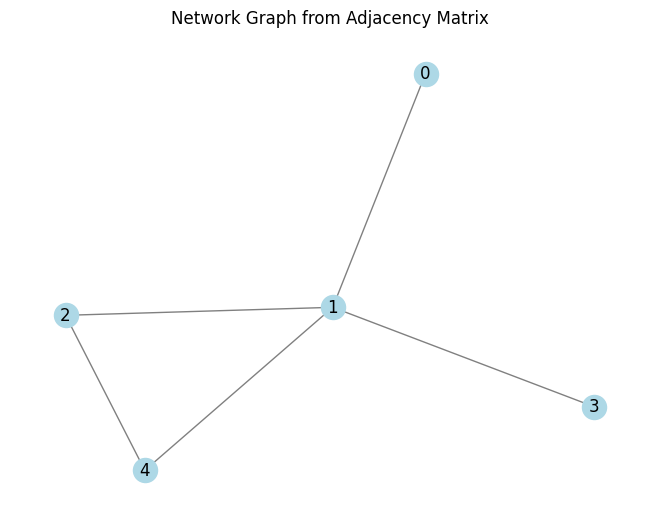

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_numpy_array(adjacency_matrix)

# Make a plot of the network
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray') 
plt.title("Network Graph from Adjacency Matrix")
plt.show()


b) Calculate the degree in every node and the average degree.


In [32]:
# b) Calculate the degree in every node and the average degree.
degrees = [G.degree(node) for node in G.nodes()]
print("Degrees of each node:", degrees)
print("Average degree:", np.mean(degrees))

Degrees of each node: [1, 4, 2, 1, 2]
Average degree: 2.0


c) Calculate the Degree, Adjacency, Incidence and Laplacian matrix. Make a heat map of each of those
matrices to evaluate them visually.

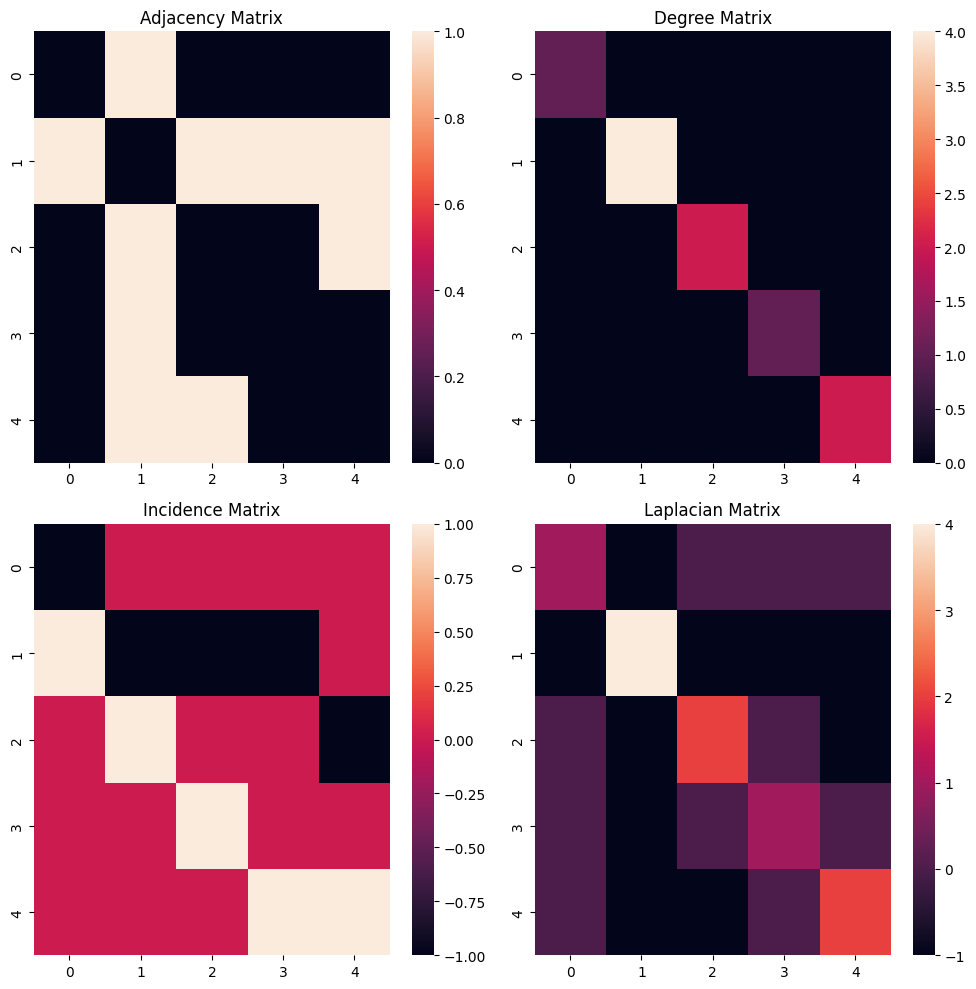

In [34]:
# c) Calculate the Degree, Adjacency, Incidence and Laplacian matrix. Make a heat map of each of those matrices to evaluate them visually.

import matplotlib.pyplot as plt
import seaborn as sns

# Degree matrix
degree_matrix = np.diag([G.degree(node) for node in G.nodes()])

# Incidence matrix
incidence_matrix = nx.incidence_matrix(G, oriented=True).toarray()

# Laplacian matrix
laplacian_matrix = degree_matrix - adjacency_matrix

# Plot heatmaps
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.heatmap(adjacency_matrix, ax=axes[0,0], annot=False)
axes[0,0].set_title("Adjacency Matrix")

sns.heatmap(degree_matrix, ax=axes[0,1], annot=False)
axes[0,1].set_title("Degree Matrix")

sns.heatmap(incidence_matrix, ax=axes[1,0], annot=False)
axes[1,0].set_title("Incidence Matrix")

sns.heatmap(laplacian_matrix, ax=axes[1,1], annot=False)
axes[1,1].set_title("Laplacian Matrix")

plt.tight_layout()
plt.show()

### Problem 4.4. 
In this problem, we will evaluate the transmission grid in Europe using data from ENTSOE
and the Python package networkX.

Using the simplified dataset of the European high-voltage transmission network whose data is contained
in the files ’data/nodes.csv’ and ’data/edges.csv’:

a) Create a network object using
nx.from_pandas_edgelist()
and calculate the average degree

In [ ]:
# Load data
data_nodes = pd.read_csv('nodes.csv')   # Columns: Bus,x,y
data_edges = pd.read_csv('edges.csv')   # Columns: Line,bus0,bus1,s_nom,x_pu

# a) 
G = nx.from_pandas_edgelist(data_edges, source='bus0', target='bus1', edge_attr=True)
degrees = [G.degree(node) for node in G.nodes()]
print("Average degree:", np.mean(degrees))

Average degree: 2.920158550396376


b) Add the information on the position of each node provided in ’data/nodes.csv’ and make a plot of the
network.

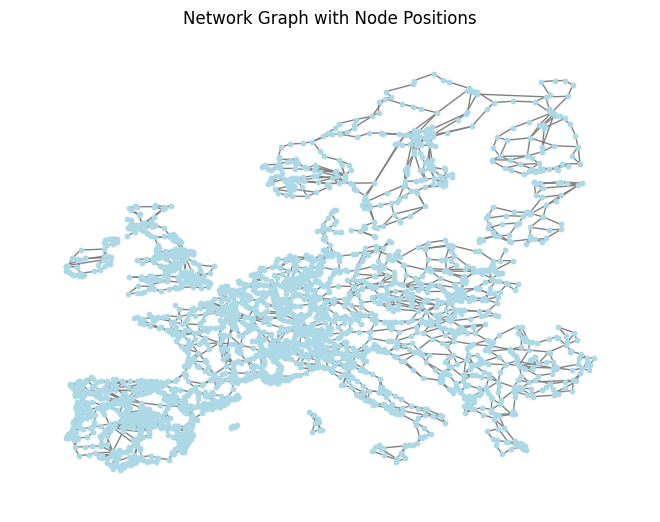

In [41]:
# b) 
pos = dict(zip(data_nodes['Bus'], zip(data_nodes['x'], data_nodes['y'])))
nx.draw(G, pos=pos, with_labels=False, node_color='lightblue', edge_color='gray', node_size=10) 
plt.title("Network Graph with Node Positions")
plt.show()

c) Determine how many independent networks exist (these are the synchronous zones of the European
transmission network).

In [58]:
# c) 
components = list(nx.connected_components(G))
print(f"Number of independent networks (connected components): {len(components)}")

Number of independent networks (connected components): 7


d) For the synchronous zone corresponding to Scandinavia, calculate the number of nodes and edges.
Calculate the Degree, Adjacency, Incidence, and Laplacian matrices. Make a heat map of each of those
matrices to evaluate them visually

In [ ]:
# d)

# Component with highest average y-coordinate is typically the Nordic area
def avg_y(comp):
    ys = [pos[n][1] for n in comp if n in pos]
    return np.mean(ys) if len(ys) else -np.inf

scand_comp = max(components, key=avg_y)
G_scand = G.subgraph(scand_comp).copy()

print("Scandinavia synchronous zone:")
print("  Nodes:", G_scand.number_of_nodes())
print("  Edges:", G_scand.number_of_edges())

Scandinavia synchronous zone:
  Nodes: 304
  Edges: 437


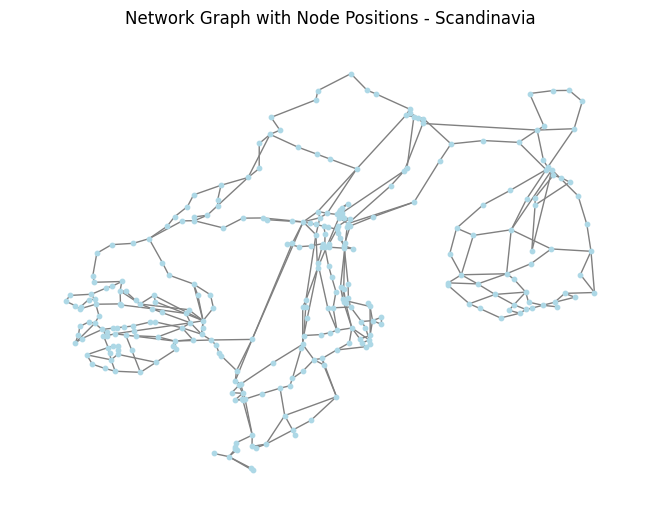

In [69]:
nx.draw(G_scand, pos=pos, with_labels=False, node_color='lightblue', edge_color='gray', node_size=10) 
plt.title("Network Graph with Node Positions - Scandinavia")
plt.show()

In [76]:
# Calculate the Degree, Adjacency, Incidence, and Laplacian matrices. 

# Degree matrix
D = np.diag([G_scand.degree(n) for n in G_scand.nodes()])

# Adjacency matrix
A = nx.adjacency_matrix(G_scand).toarray()

# Incidence matrix (assuming undirected graph)
I = nx.incidence_matrix(G_scand, nodelist=sorted(G_scand.nodes())).toarray()

# Laplacian matrix
L = D - A


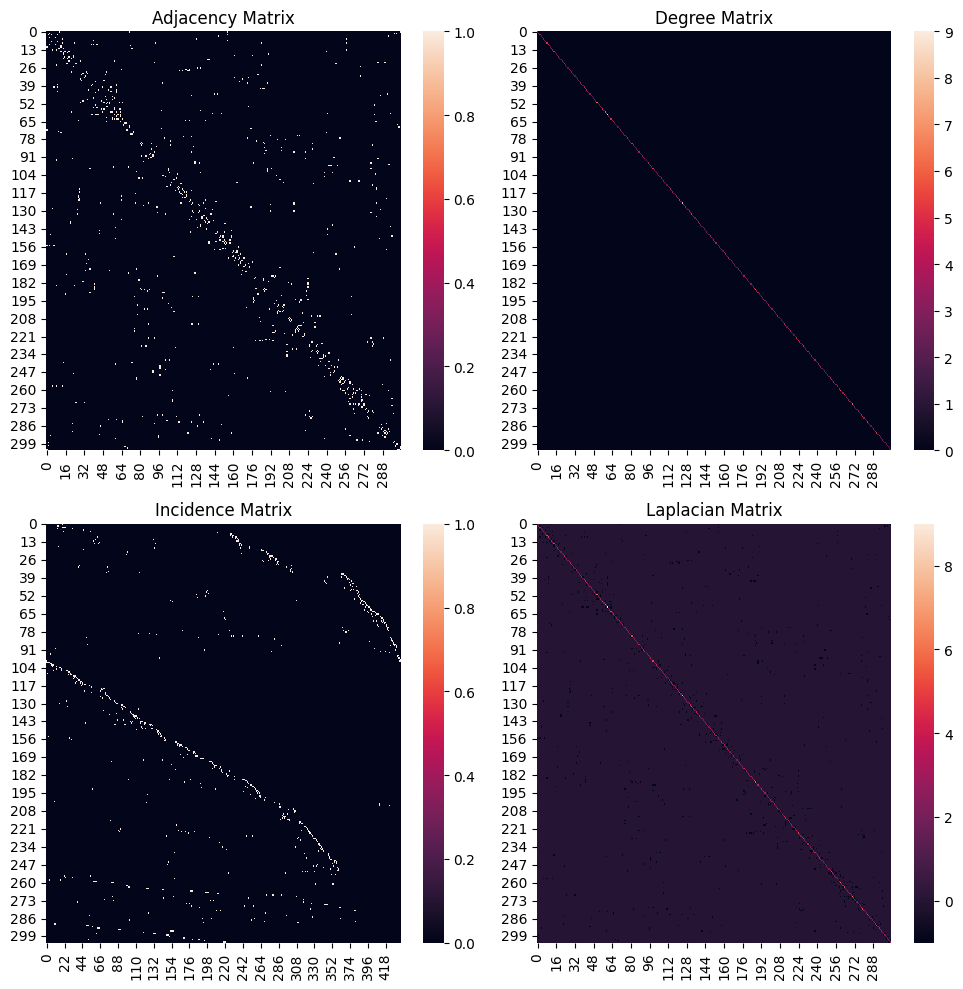

In [79]:
# Plot heatmaps of each matrix
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
sns.heatmap(A, ax=axes[0,0], annot=False)
axes[0,0].set_title("Adjacency Matrix")
sns.heatmap(D, ax=axes[0,1], annot=False)
axes[0,1].set_title("Degree Matrix")
sns.heatmap(I, ax=axes[1,0], annot=False)
axes[1,0].set_title("Incidence Matrix")
sns.heatmap(L, ax=axes[1,1], annot=False)
axes[1,1].set_title("Laplacian Matrix")
plt.tight_layout()
plt.show()

In [85]:
print("Row sums ~ 0:", np.allclose(L.sum(axis=1), 0))

Row sums ~ 0: True


Visual evaluation of heatmap:

Adj. matrix:
- The matrix is mostly zeros → transmission grids are sparse (avg degree small relative to n=304).
- Symmetry about diagonal → confirms undirected representation.
- The “banded / clustered” structure suggests some geographic grouping or ordering effect (because nodes were sorted numerically, which probably correlates with geography).

Deg. matrix:
- Only diagonal entries nonzero.
- Values range up to ~9. Degree up to ~9 is very reasonable for a transmission node.
- No off-diagonal structure → correct.

Inc. matrix:
- Correct dimensions (304 x 437), so each edge connects exactly two nodes
- Wondering why the scale does not have -1

Lap. matrix:
- Most values are 1, diagonal is mostly around 3-4, some negative values scattered
- Meaning the nodes in the diagonal have multiple connections to other nodes
- Symmetric with diagonal dominance
- Negative values (-1) where adj. had 1's (good)
- Rows sum to 0
